In [48]:
import pandas as pd
import sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sys.path.append(r"D:/Football Project/src")

import feature_lists_3yr as fl

In [49]:
df=pd.read_csv("D:/Football Project/data/processed/3_year/Avg_Top5_Leagues.csv")

In [50]:
df=df[df['position']=='Goalkeepers']

In [51]:
df.head()

,player id,player,team,team id,league,position,number_of_seasons,appearances,accuratechippedpasses,accuratecrosses,...,assist_conversion,xa_per_keypass,final_third_pass_pct,opp_half_pass_pct,dribbles_per_touch,dispossessed_per_touch,possession_lost_per_touch,defensive_actions,defensive_actions_per90,weak_foot_goals_pct
1,2899,Daniele Padelli,Udinese,2695,Italy Serie A,Goalkeepers,2,1.500000,0.500000,0.0,...,NaN,NaN,0.000000,0.054545,0.000000,0.000000,0.260000,11.000000,7.333333,NaN
4,8959,Manuel Neuer,FC Bayern München,2672,Germany Bundesliga,Goalkeepers,3,22.333333,61.333333,0.0,...,0.0,0.140000,0.029488,0.090533,0.000707,0.000000,0.138163,168.666667,7.726502,NaN
7,15219,Lukáš Hrádecký,AS Monaco,1653,France Ligue 1,Goalkeepers,3,26.333333,49.333333,0.0,...,NaN,NaN,0.020337,0.111501,0.000000,0.000000,0.212709,198.333333,7.627119,NaN
9,16206,Yann Sommer,Inter,2697,Italy Serie A,Goalkeepers,3,33.333333,59.000000,0.0,...,NaN,NaN,0.012632,0.068421,0.000000,0.000000,0.126254,207.333333,6.226226,NaN
15,22209,Ørjan Nyland,Sevilla,2833,Spain La Liga,Goalkeepers,3,19.666667,29.000000,0.0,...,0.0,0.021667,0.078607,0.238806,0.000000,0.000451,0.323105,145.000000,7.409160,NaN


In [52]:
creation_to_keep = ['accurateoppositionhalfpasses_per90', 'accuratelongballspercentage', 'accuratelongballs_per90', 'assists_per90', 'totalpasses_per90', 'passtoassist_per90', 'accuratepassespercentage']
possession_to_keep = ['touches_per90', 'possesionlost_per90', 'interceptions_per90', 'blockedshots_per90', 'errorleadtogoal_90', 'errorleadtoshot_per90', 'dribbledpad_per90']
duels_to_keep = ['aerialduelswonpercentage', 'aerialduelswon_per90']
discipline_to_keep = ['owngoals_per90']

columns_to_drop = (
    fl.attacking_features +
    [col for col in fl.creation_features if col not in creation_to_keep] +
    [col for col in fl.possession_features if col not in possession_to_keep] +
    [col for col in fl.duel_features if col not in duels_to_keep] +
    [col for col in fl.discipline_features if col not in discipline_to_keep]
)

df = df.drop(columns=columns_to_drop)

In [53]:
df = df[df["minutesplayed"]>540]

In [54]:
df.shape

(140, 76)

In [55]:
df.head()

,player id,player,team,team id,league,position,number_of_seasons,appearances,ballrecovery,blockedshots,...,goalsprevented_per90,runsout_per90,successfulrunsout_per90,goalkicks_per90,punches_per90,highclaims_per90,crossesnotclaimed_per90,owngoals_per90,defensive_actions,defensive_actions_per90
4,8959,Manuel Neuer,FC Bayern München,2672,Germany Bundesliga,Goalkeepers,3,22.333333,168.000000,0.0,...,-0.047031,0.671870,0.626060,3.573125,0.244316,0.290126,0.030540,0.0,168.666667,7.726502
7,15219,Lukáš Hrádecký,AS Monaco,1653,France Ligue 1,Goalkeepers,3,26.333333,198.000000,0.0,...,-0.031662,0.410198,0.384561,4.909557,0.192280,0.551204,0.000000,0.0,198.333333,7.627119
9,16206,Yann Sommer,Inter,2697,Italy Serie A,Goalkeepers,3,33.333333,206.666667,0.0,...,0.045846,0.200200,0.180180,4.644645,0.250250,0.410410,0.010010,0.0,207.333333,6.226226
15,22209,Ørjan Nyland,Sevilla,2833,Spain La Liga,Goalkeepers,3,19.666667,144.000000,0.0,...,0.008516,0.425814,0.357684,6.659727,0.323618,0.545042,0.000000,0.0,145.000000,7.409160
24,37096,Péter Gulácsi,RB Leipzig,36360,Germany Bundesliga,Goalkeepers,3,22.000000,165.000000,0.0,...,0.049716,0.464636,0.464636,6.055756,0.480124,0.665978,0.015488,0.0,165.333333,7.681982


In [56]:
df_desc=df.drop(columns=fl.metadata_features).describe().transpose()

In [57]:
with pd.option_context('display.max_rows', None, 'display.max_colwidth', None):
    display(df_desc)

,count,mean,std,min,25%,50%,75%,max
number_of_seasons,140.0,2.500000,0.724693,1.000000,2.000000,3.000000,3.000000,3.000000
appearances,140.0,24.177381,8.781867,6.500000,16.375000,26.166667,32.000000,38.000000
ballrecovery,140.0,194.447619,77.450962,44.000000,135.375000,197.833333,255.666667,337.666667
blockedshots,140.0,0.015476,0.084575,0.000000,0.000000,0.000000,0.000000,0.666667
cleansheet,140.0,6.351190,3.275987,1.000000,4.000000,6.166667,8.083333,16.000000
clearances,140.0,23.540476,10.566392,4.666667,15.333333,22.583333,30.000000,52.500000
crossesnotclaimed,140.0,0.386905,0.499507,0.000000,0.000000,0.333333,0.541667,3.000000
dribbledpast,140.0,0.845238,0.828799,0.000000,0.333333,0.666667,1.000000,5.000000
errorleadtogoal,140.0,1.134524,0.913724,0.000000,0.500000,1.000000,1.666667,6.000000
errorleadtoshot,140.0,1.098810,0.991349,0.000000,0.333333,1.000000,1.500000,4.666667


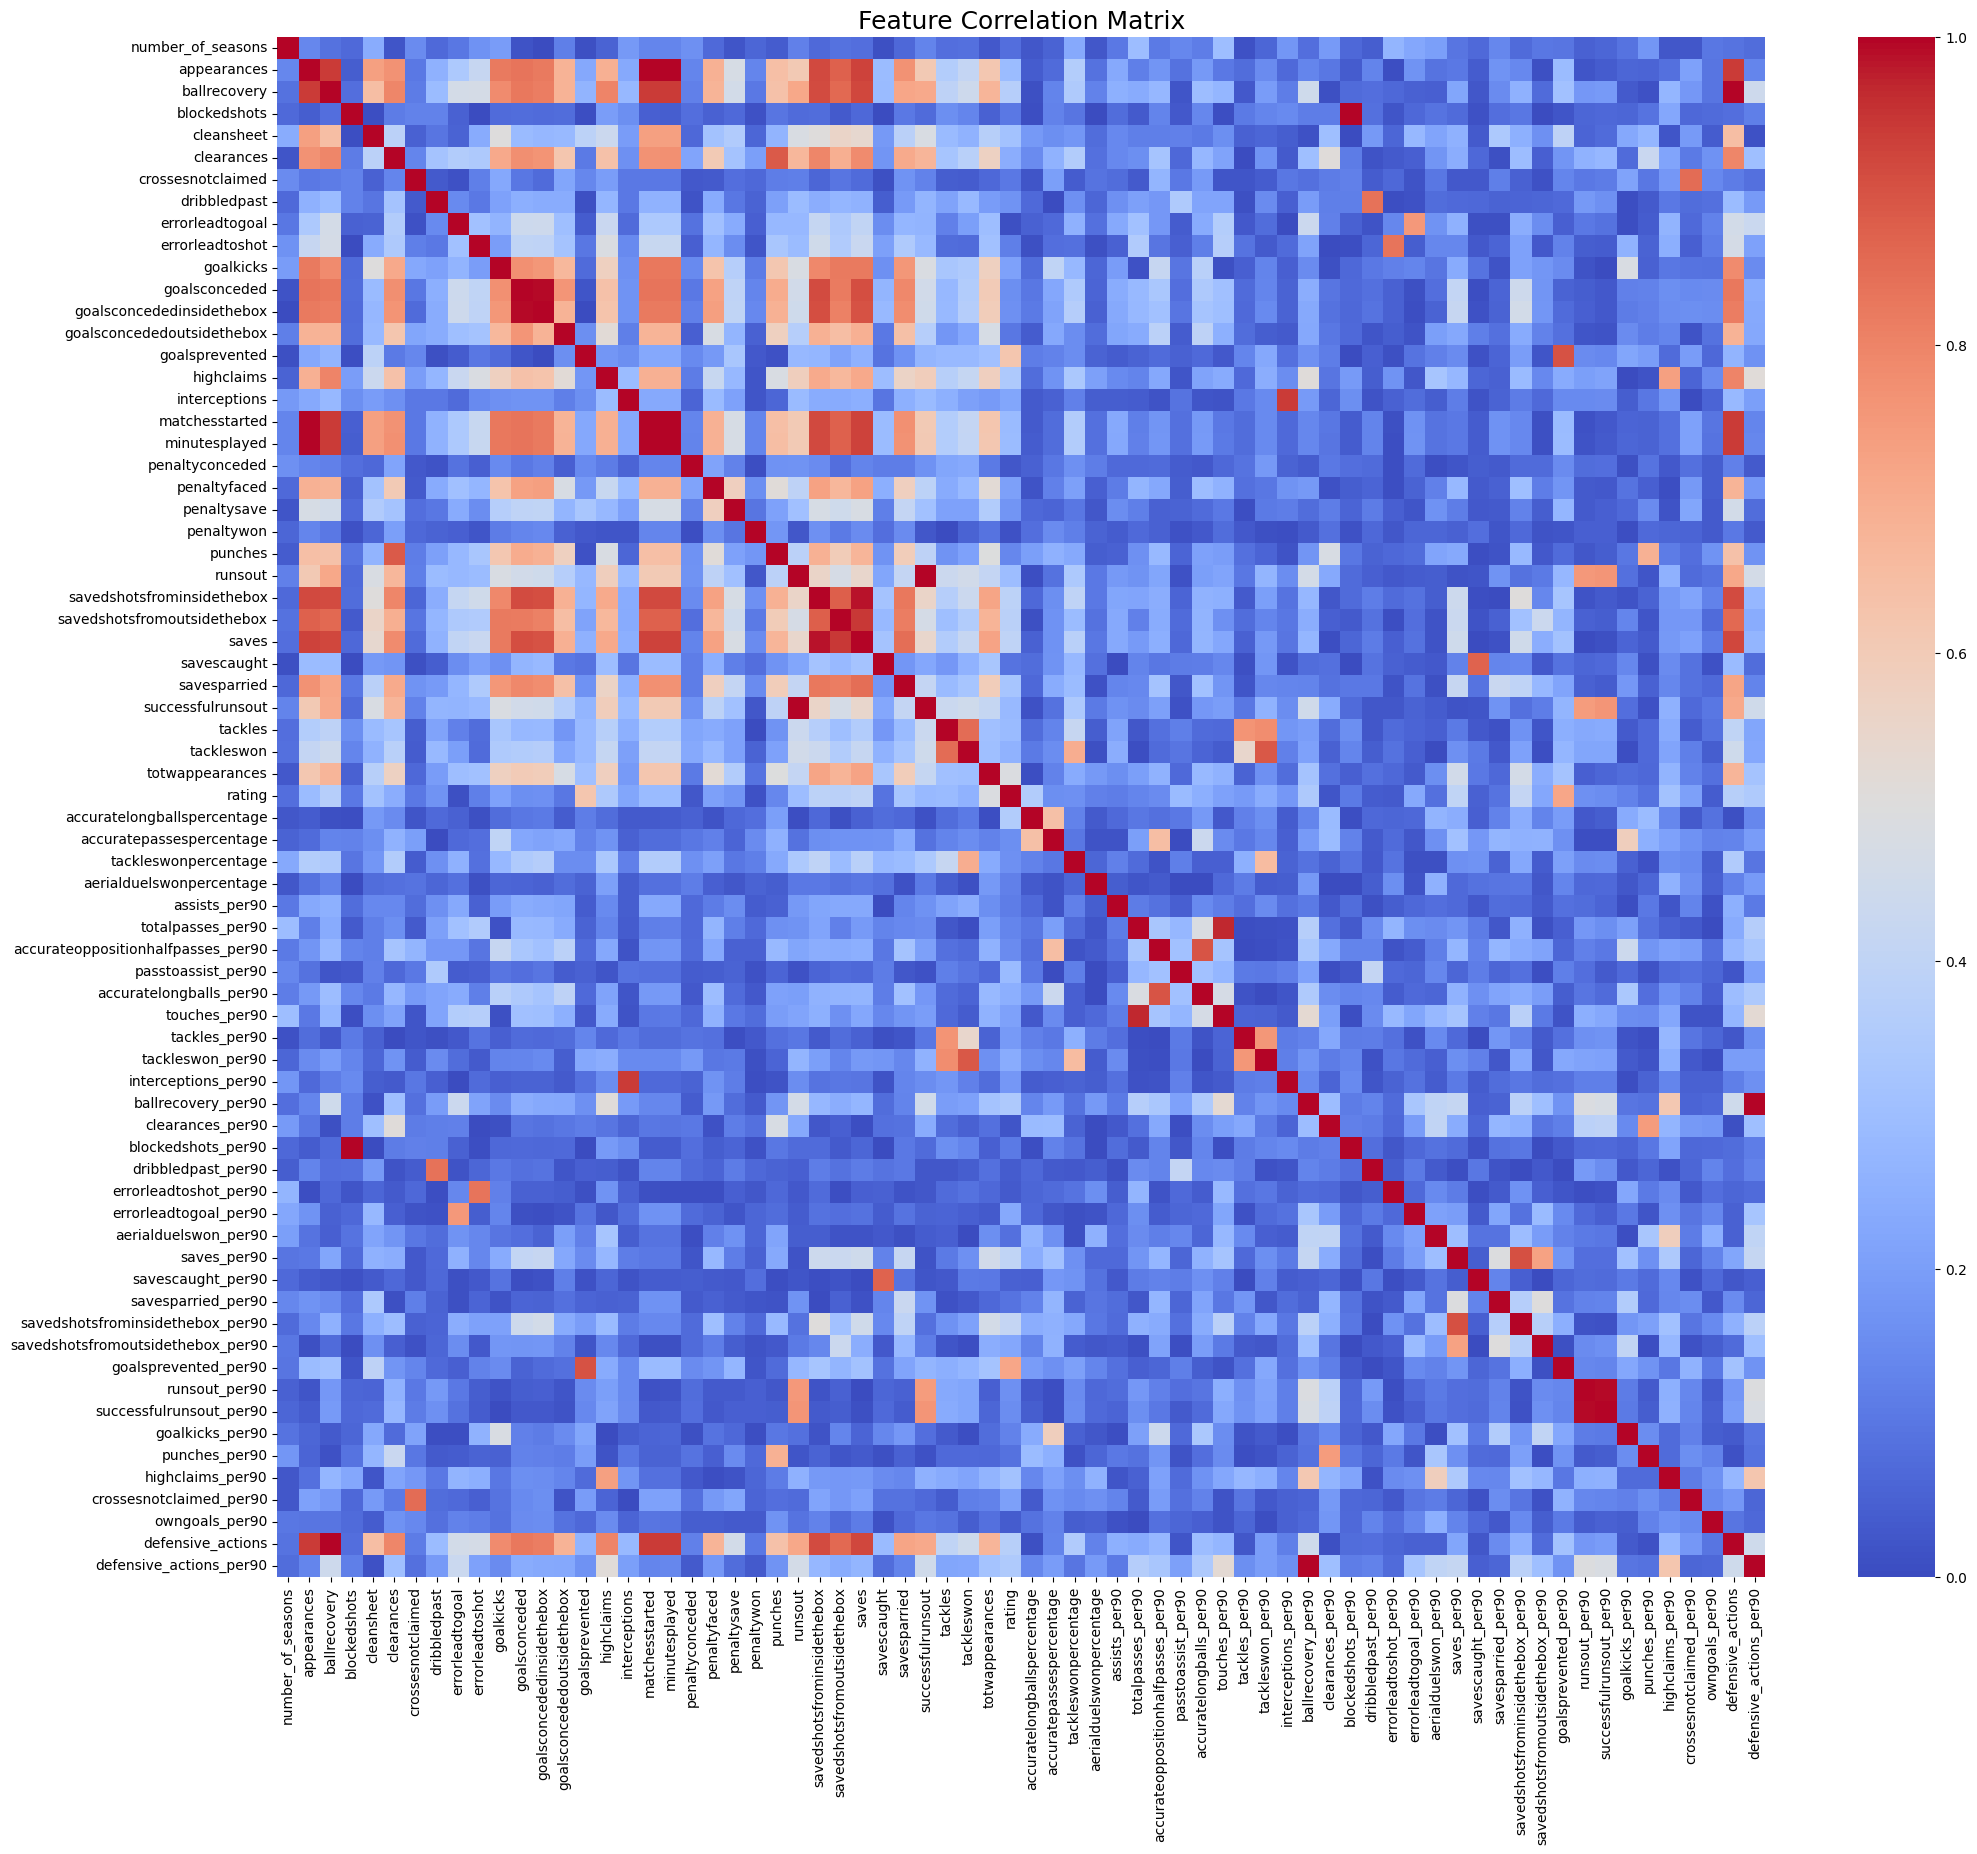

In [58]:
corr_matrix = df.drop(columns=fl.metadata_features).corr().abs()

plt.figure(figsize=(24, 20))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, vmin=0, vmax=1)
plt.title("Feature Correlation Matrix", fontsize=18)
plt.show()

In [59]:
corr_pairs = corr_matrix.unstack()
high_corr = corr_pairs[(corr_pairs > 0.80) & (corr_pairs < 1.0)].drop_duplicates().sort_values(ascending=False)

high_corr_df = pd.DataFrame(high_corr).reset_index()
high_corr_df.columns = ['Feature_1', 'Feature_2', 'Correlation']

with pd.option_context('display.max_rows', None, 'display.max_colwidth', None):
    display(high_corr_df)

,Feature_1,Feature_2,Correlation
0,ballrecovery,defensive_actions,0.999956
1,matchesstarted,minutesplayed,0.999687
2,appearances,minutesplayed,0.999649
3,appearances,matchesstarted,0.999535
4,ballrecovery_per90,defensive_actions_per90,0.999440
5,blockedshots,blockedshots_per90,0.997463
6,runsout,successfulrunsout,0.997151
7,runsout_per90,successfulrunsout_per90,0.994188
8,goalsconceded,goalsconcededinsidethebox,0.993739
9,savedshotsfrominsidethebox,saves,0.986109


In [60]:
columns_to_drop = [
    "appearances",
    "savedshotsfrominsidethebox_per90",
    "cleansheet",
    "crossesnotclaimed",
    "errorleadtogoal",
    "errorleadtoshot",
    "highclaims",
    "punches",
    "totalpasses_per90",
    "matchesstarted",
    "attemptpenaltymiss",
    "attemptpenaltypost",
    "attemptpenaltytarget",
    "saves",
    "savedshotsfrominsidethebox",
    "savedshotsfromoutsidethebox",
    "goalsconceded",
    "goalsconcededinsidethebox",
    "goalsconcededoutsidethebox",
    "savesparried",
    "savescaught",
    "touches",
    "touches_per90",
    "accurateoppositionhalfpasses_per90",
    "ballrecovery",
    "ballrecovery_per90",
    "defensive_actions",
    "defensive_actions_per90",
    "clearances",
    "clearances_per90",
    "goalkicks",
    "runsout",
    "runsout_per90",  
    "successfulrunsout",
    "blockedshots",
    "blockedshots_per90",
    "possessionwonattthird",
    "possessionwonattthird_per90",
    "interceptions",
    "interceptions_per90",
    "tackles",
    "tackles_per90",
    "tackleswon",
    "tackleswon_per90",
    "dribbledpast",
    "dribbledpast_per90",
    "passtoassist_per90",
    "assists",
    "assists_per90",
    "penaltyconceded",
    "penaltyfaced",
    "penaltysave",
    "penaltywon",
    "owngoals",
    "totwappearances",
]

df = df.drop(columns=columns_to_drop, errors="ignore")

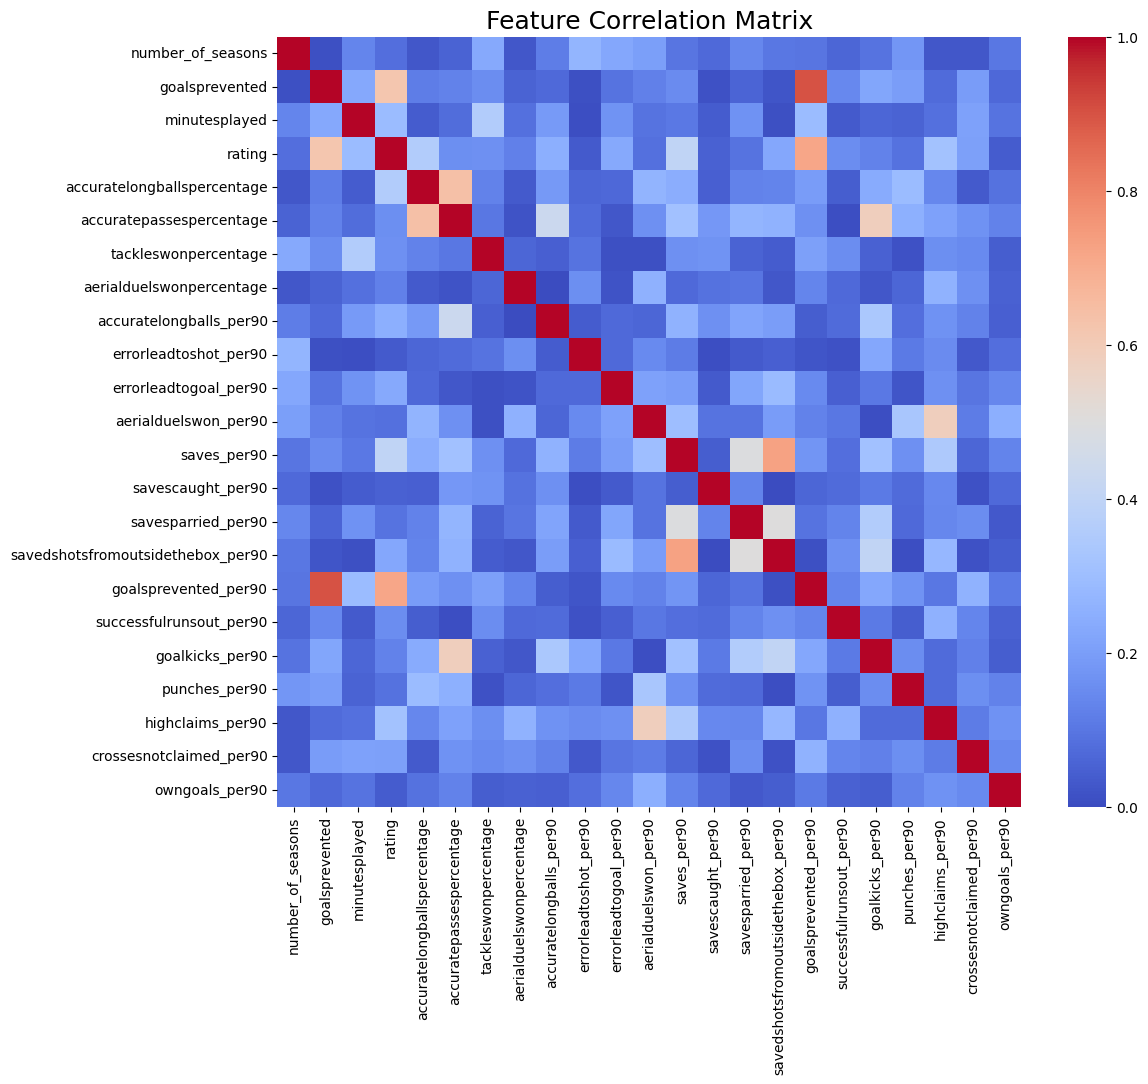

In [61]:
corr_matrix = df.drop(columns=fl.metadata_features).corr().abs()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, vmin=0, vmax=1)
plt.title("Feature Correlation Matrix", fontsize=18)
plt.show()

In [62]:
targets=['Joan García','Thibaut Courtois','Gianluigi Donnarumma','Mike Maignan','David Raya','Manuel Neuer','Alisson']
view_df=df.copy()
view_df['highlight'] = view_df['player'].isin(targets).astype(int)

In [63]:
fig = px.scatter(
    view_df.copy(), 
    x='minutesplayed', 
    y='goalsprevented_per90',
    color='highlight',
    hover_name='player',         
    hover_data=['team','rating','number_of_seasons','goalsprevented'], 
    title='Goalkeeper Performance',
    labels={
        'minutesplayed': 'Minutes Played',
        'goalsprevented_per90': 'Goals Prevented per 90'
    },
    template='plotly_white',               
    width=1000, 
    height=600
)

fig.update_traces(marker=dict(size=10, opacity=0.8, line=dict(width=1, color='DarkSlateGrey')))

fig.show()

In [64]:
fig = px.scatter(
    view_df.copy(), 
    x='minutesplayed', 
    y='errorleadtoshot_per90',
    color='highlight',
    hover_name='player',         
    hover_data=['team','rating','number_of_seasons','goalsprevented'],
     
    title='Goalkeeper Performance',
    labels={
        'minutesplayed': 'Minutes Played',
        'goalsprevented_per90': 'Goals Prevented per 90'
    },
    template='plotly_white',               
    width=1000, 
    height=600
)

fig.update_traces(marker=dict(size=10, opacity=0.8, line=dict(width=1, color='DarkSlateGrey')))

fig.show()

In [65]:
df.to_csv('../../../data/processed/3_year/Goalkeeper/Avg_Top5_Goalkeepers.csv',index=False)